# testing HBV from .py 

In [14]:
# setup imports
import sys
from pathlib import Path
import numpy as np
import xarray as xr
PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from src.paths import *
from src.forcing import setup_ERA5_forcing,plot_ERA5_forcing,load_lumped_forcing,setup_ERA5_PCR_forcing
from src.models import run_HBV_model,plot_HBV_output,save_HBV_results
from src.utils import catchment_area_from_shapefile, get_integer_multiple_bounds

In [3]:
# The time-window of the experiment
experiment_start_date = "1940-01-01T00:00:00Z"
experiment_end_date = "1990-12-31T00:00:00Z"

shapefile_name = "Tyumen_Aryk_GRDC"

#ERA5_forcing = setup_ERA5_forcing(shapefile_name, experiment_start_date, experiment_end_date)
#ERA5_forcing = load_lumped_forcing(shapefile_name, , )



In [4]:
ERA5_forcing_loaded = load_lumped_forcing("Tyumen_Aryk_GRDC", "ERA5", "1940-1990")

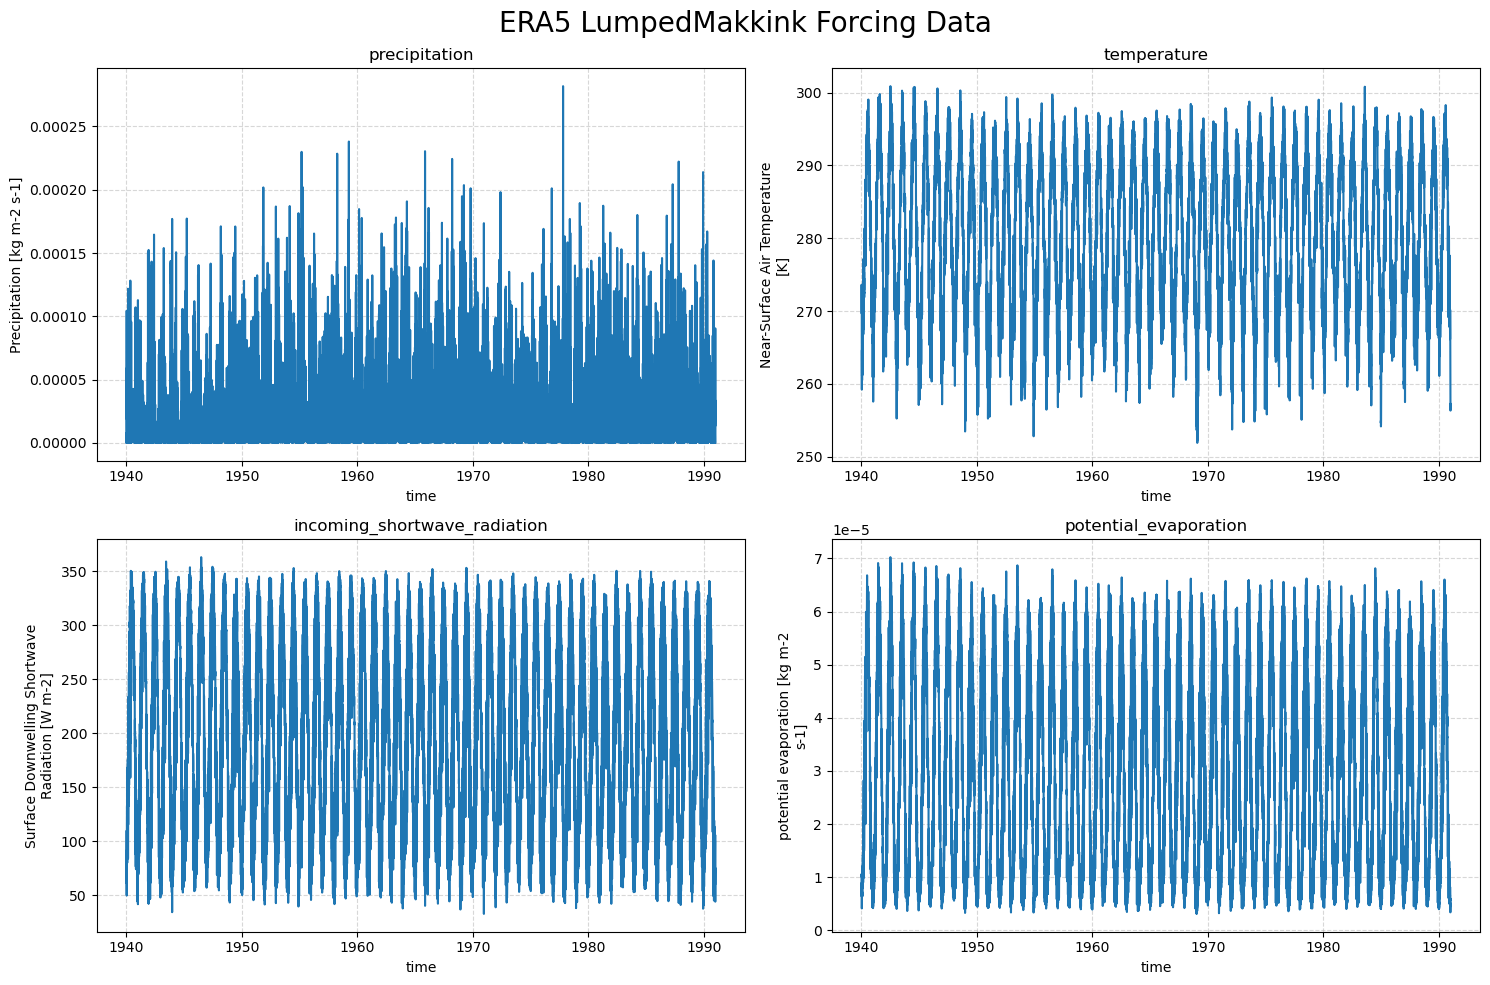

In [5]:
plot_ERA5_forcing(ERA5_forcing_loaded)

# HBV model run

In [6]:
parameter_set =  [
    7.085,  # Imax
    0.837,  # Ce
    76.373, # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226   # FM
]

initial_conditions = np.array([
    0,      # Si
    100,    # Su
    0,      # Sf
    5,      # Ss
    0       # Sp
])

In [7]:

Q_modelled = run_HBV_model(
    forcing=ERA5_forcing_loaded,
    parameter_set=parameter_set,
    initial_conditions=initial_conditions,
    show_progress=True  # shows tqdm progress bar
)


print(Q_modelled.head())

Running HBV model:   0%|          | 0/18627 [00:00<?, ?it/s]

1940-01-02 12:00:00    0.000498
1940-01-03 12:00:00    0.002021
1940-01-04 12:00:00    0.004623
1940-01-05 12:00:00    0.008359
1940-01-06 12:00:00    0.012284
Name: Modelled_discharge, dtype: float64


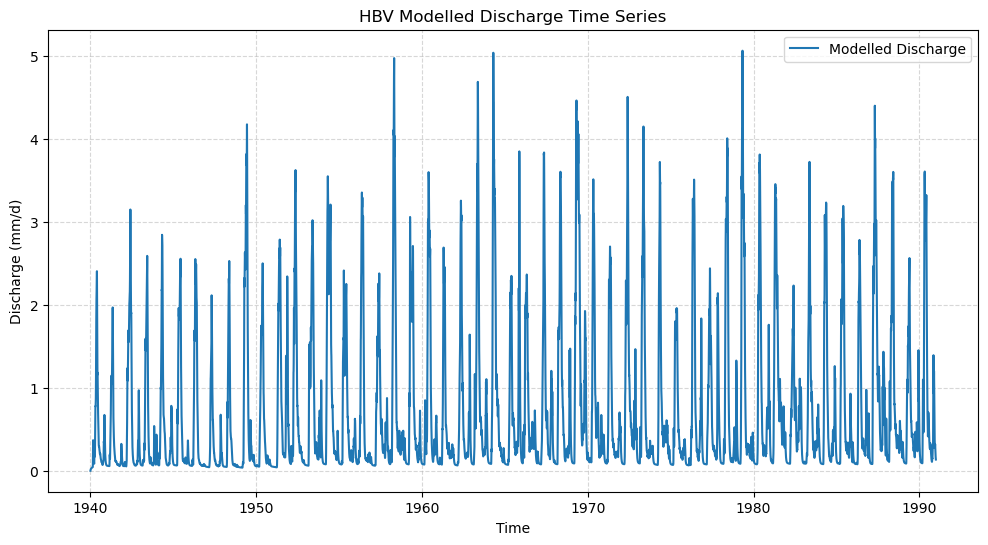

In [8]:
plot_HBV_output(Q_modelled)

In [9]:
files= save_HBV_results(Q_modelled, shape_name=shapefile_name, forcing_type="ERA5")

In [10]:
#Determine bounding box
shape_name = "Chatly_GRDC"
shapefile = SHAPEFILES / shape_name / f"{shape_name}.shp"

lon_min_f, lat_min_f, lon_max_f, lat_max_f = get_integer_multiple_bounds(
    shapefile, #   <----- add shapefiles here
    multiple=3, #makes sure resolution is always correct
)
print(lon_min_f, lat_min_f, lon_max_f, lat_max_f)

59 34 77 43


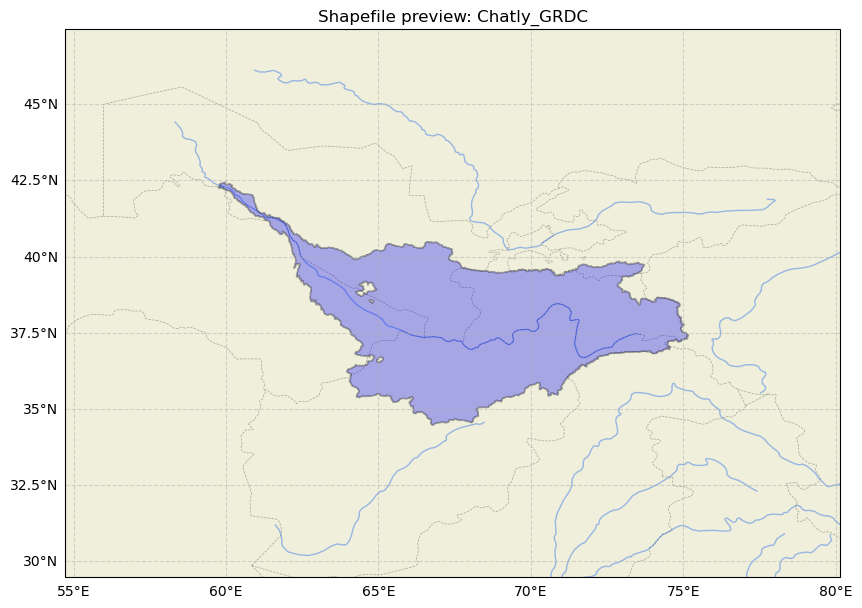

In [11]:
import fiona
from shapely.geometry import shape, Polygon, MultiPolygon
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

shp = SHAPEFILES / shape_name / f"{shape_name}.shp"

# Create figure and Cartopy axes
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add background features
ax.add_feature(cfeature.OCEAN, facecolor = "#a2daff", edgecolor="none")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.RIVERS, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle = "--", alpha=0.3)

# Plot shapefile geometries
with fiona.open(shp) as src:
    for feat in src:
        geom = shape(feat["geometry"])
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), facecolor="blue", edgecolor="black", alpha=0.3)

# Set extent to shapefile bounds (with small padding)
with fiona.open(shp) as src:
    minx, miny, maxx, maxy = src.bounds
ax.set_extent([minx-5, maxx+5, miny-5, maxy+5], crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Add title
ax.set_title(f"Shapefile preview: {shape_name}")

plt.show()


In [ ]:
# experiment_start_date = "1940-01-01T00:00:00Z"
# experiment_end_date = "1940-05-31T00:00:00Z"
# PCR_Forcing = setup_ERA5_PCR_forcing("AralSea_basin",experiment_start_date,experiment_end_date)

In [12]:
print(PCR_Forcing)

start_time='1940-01-01T00:00:00Z' end_time='1940-05-31T00:00:00Z' directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1940/AralSea_basin/work/diagnostic/script') shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/shapefiles/AralSea_basin/AralSea_basin.shp') filenames={} precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1940_AralSea_basin.nc' temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-1940_AralSea_basin.nc'


<xarray.Dataset> Size: 29MB
Dimensions:    (time: 731, lat: 89, lon: 113, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 6kB 1939-01-01 1939-01-02 ... 1940-12-31
  * lat        (lat) float32 356B 54.0 53.75 53.5 53.25 ... 32.5 32.25 32.0
  * lon        (lon) float32 452B 55.0 55.25 55.5 55.75 ... 82.5 82.75 83.0
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 29MB 265.2 265.4 265.6 ... 258.0 257.6
    time_bnds  (time, bnds) datetime64[ns] 12kB 1938-12-31T12:00:00 ... 1940-...
    lat_bnds   (lat, bnds) float32 712B 54.12 53.88 53.88 ... 32.12 32.12 31.88
    lon_bnds   (lon, bnds) float32 904B 54.88 55.12 55.12 ... 82.88 82.88 83.12
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the PCR-GLOBWB hydrological model.
------------------------
<xarray.Dataset> Size: 29MB
Dimensions:    (time: 731, lat: 89, lon: 113, bnds: 2)
Coordinate

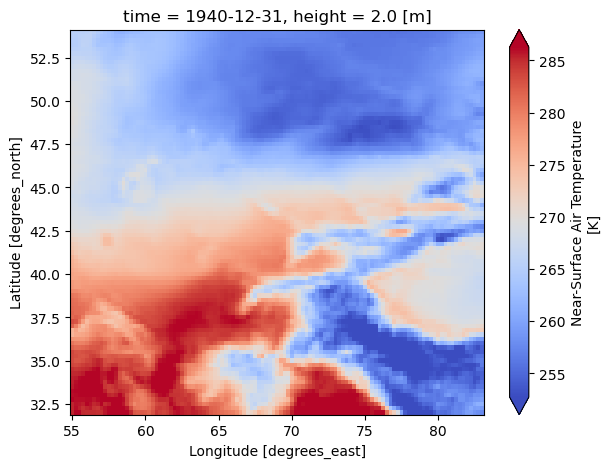

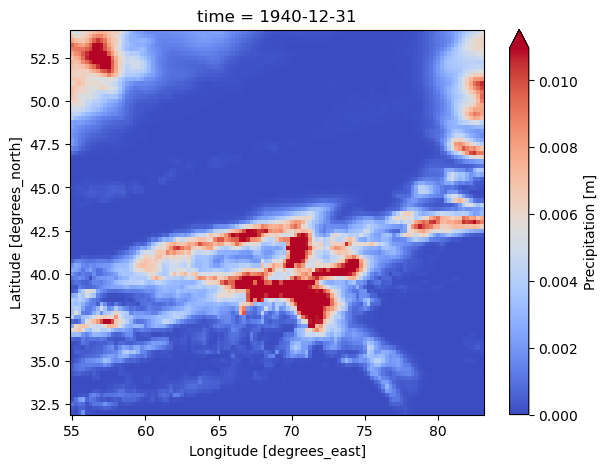

In [19]:
for file_name in [PCR_Forcing.temperatureNC, PCR_Forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{PCR_Forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)